***TASK 1***

الخلية الأولى:
سنخصصها لاستيراد المكتبات اللازمة لإنجاز المهام
وهي بديهية ولا تحتاج توضيحات منعاً للإطالة

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#الخلية الثانية:
 تحتوي على تعليمة خاصة بضبط نمط الرسوم البيانية
 قمنا بإدراجها بعد استيراد المكتبات كعادة برمجية جيدة سنقوم باستخدامها لاحقاً

In [ ]:
sns.set_style("whitegrid")

#الخلية الثالثة


1.   تحميل مجموعة البيانات من sklearn
2.   اسناد السمات والأهداف إلى متحولات لسهولة التعامل معها أي إنشاء إطار بيانات



In [ ]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

#الخلية الرابعة:
معاينة البيانات
إظهار عدد السمات وعدد الأهداف
عرض أسماء تصنيفات الهدف

In [ ]:
print("Features", X.shape)
print("Target", y.shape)
print("\nأسماء فئات الهدف:", data.target_names)

Features (569, 30)
Target (569,)

أسماء فئات الهدف: ['malignant' 'benign']


#الخلية الخامسة

---


معاينة فعلية لأول خمس تسجيلات من مجموعة البيانات

In [ ]:
print(X.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

#الخلية السادسة
تظهر هذه التعليمة توصيف مجموعة البيانات بشكل مفصل من حيث طبيعة السمات بالإضافة إلى معلومات إحصائية وكذلك حقوق التأليف لمجموعة البيانات

In [ ]:
print(data.DESCR)

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

#الخلية السابعة
سنتحقق من نظافة البيانات
بشكل أساسي سنقوم بالتحقق من وجود أي قيم مفقودة وسنستخدم التابع isnull
الفكرة هنا سنقوم بالنسبة لكل سمة أو عمود بالتحقق من وجود قيم مفقودة وإذا لم يتم إيجاد قيم مفقودةلا حاجة للتدخل في البيانات أو معالجتها


In [ ]:
missing_values = X.isnull()
print(missing_values)


     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0          False         False           False      False            False   
1          False         False           False      False            False   
2          False         False           False      False            False   
3          False         False           False      False            False   
4          False         False           False      False            False   
..           ...           ...             ...        ...              ...   
564        False         False           False      False            False   
565        False         False           False      False            False   
566        False         False           False      False            False   
567        False         False           False      False            False   
568        False         False           False      False            False   

     mean compactness  mean concavity  mean concave points  mea

بسبب العدد الكبير نسبياً للسمات "30 سمة" سنقوم باستخدام التابع sum()
سيقوم هذا التابع بجمع عدد التسجيلات الفارغة من أجل كل سمة وإظهارها على شكل قائمة وسيساعدنا ذلك في التحقق من النتائج
\\

In [ ]:
missing_values_sum = X.isnull().sum()
print(missing_values_sum)

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64


قمنا في الخلايا الثمان الأولى بما يمكن أن نسميه "استطلاع للبيانات " من دون أن نقوم بأي تغيير على بينة هذه البيانات
الخطوة التالية ستكون معالجة البيانات التي ستؤدي إلى تغيير في بنية البيانات  

#معالجة البيانات الأولية
أولا بما أن قيم السمات ال30 الخاصة بمجموعة البيانات لها مجالات مختلفة والتي يمكن أن تؤثر على خوارزميات التصنيف بشكل سلبي حيث ستسبب انزياح التصنيف بطريقة غير عادلة إن صح التعبير، لا بد لنا من إجراء عملية تقييس لقيم السمات في الدخل حتى نوحد المتوسط الحسابي عند القيمة 0 والانحراف المعياري عند القيمة 1

توفر المكتبة sklearn صف جاهز لإتمام المهمة

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

معاينة أول 5 تسجيلات قبل التقييس و بعد التقييس
نلاحظ الحصول على متوسط مقبول أي قريب من الصفر بالنسبة لقيم السمات
وكذلك الحصول عهلى انحراف معياري ممتاز كاد أن يطابق ال 1

In [ ]:
print("The mean before standardization or normalization \n", X.iloc[:, :5].mean())
print("The mean after standardization or normalization \n", X_scaled_df.iloc[:, :5].mean())
print("The  standard deviation before standardization or normalization \n", X.iloc[:, :5].std())
print("The  standard deviation after standardization or normalization \n", X_scaled_df.iloc[:, :5].std())

The mean before standardization or normalization 
 mean radius         14.127292
mean texture        19.289649
mean perimeter      91.969033
mean area          654.889104
mean smoothness      0.096360
dtype: float64
The mean after standardization or normalization 
 mean radius       -3.162867e-15
mean texture      -6.530609e-15
mean perimeter    -7.078891e-16
mean area         -8.799835e-16
mean smoothness    6.132177e-15
dtype: float64
The  standard deviation before standardization or normalization 
 mean radius          3.524049
mean texture         4.301036
mean perimeter      24.298981
mean area          351.914129
mean smoothness      0.014064
dtype: float64
The  standard deviation after standardization or normalization 
 mean radius        1.00088
mean texture       1.00088
mean perimeter     1.00088
mean area          1.00088
mean smoothness    1.00088
dtype: float64


***TASK 2***

#في هذه الخلية سنحاول القيام بالخطوات التي ستكون مشتركة بين جميع الخوارزميات
أي سنقوم بتنفيذ البند الأول من المهمة الثالثة تجاوزاً لضمان اتساق المشروع بما يتناسب مع طريقة مقارببتنا للحل

#تقسيم البيانات بين بيانات تدريب و بيانات اختبار حسب المطلوب في الاحتبار 70 - 30

نلاحظ استخدامنا لقيم السمات بعد التقييس أو التسوية التي قمنا بها

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df, y, test_size=0.3, random_state=42, stratify=y)

نلقي نظرة علي حجوم بيانات التدريب والاختبار
حيث نلاحظ أن التدريب سيتم على 398 عينة من المريضات
والاختبار سيتم على 171 عينة
ملاحظة يمكننا القيام بعملية التقسيم بطرق أخرى ولكن تم التركيز في هذا المشروع على المقارنة بين خوارزميات التصنيف لذلك كان لا بد من تجنب تشعب الدراسة

In [ ]:
print(f"حجم مجموعة التدريب (X_train): {X_train.shape}")
print(f"حجم مجموعة الاختبار (X_test): {X_test.shape}")

حجم مجموعة التدريب (X_train): (398, 30)
حجم مجموعة الاختبار (X_test): (171, 30)


#سنقوم في الخلية التالية باستيراد الخوارزميات الخمسة الخاصة بالمشروع
حيث سنضع عمليات الاستيراد المطلوبة في خلية واحدة لتسهيل قراءة الكود

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

#التدريب

أولاً سيتم إنشاء قاموس بالنماذج اسماؤه هي مفاتيحه هي اسماء النماذج وقيمه هي ما تعيده هذه النماذج من قيم


#في خوارزمية SVM
سنستخدم السمة probability  ونسند لها القيمة True
سيعطينا استقراء احتمالي  سنحتاجه في رسم المنحنيات لاحقاً

#في خوارزمية الجيران الأقرب اخترنا عدد الجيران 10 جيران كونها قيمة متناسبة مع المسألة

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Support Vector Machine (SVM)": SVC(probability=True, random_state=42),
    "k-Nearest Neighbors (KNN)": KNeighborsClassifier(n_neighbors=10)
}

في هذه الخلية

أولاً ننشئ قاموساً فارغاً لحفظ النماذج بعد التدريب
ثانياً ندور في حلقة على كل عنصر في القاموس الذي يضم الخوارزميات الخمسة ونقوم بتدريبها على بيانات التدريب
ثالثاً نقوم بحفظ النموذج بعد التدريب في القاموس الذي تم إنشاؤه

In [ ]:
trained_models = {}
for name, model in models.items():
    print(f"TRAINING MODEL: {name}...")
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"TRAINING COMPLETE : {name}.\n")
print("All classifiers trained!")

TRAINING MODEL: Logistic Regression...
TRAINING COMPLETE : Logistic Regression.

TRAINING MODEL: Naive Bayes...
TRAINING COMPLETE : Naive Bayes.

TRAINING MODEL: Decision Tree...
TRAINING COMPLETE : Decision Tree.

TRAINING MODEL: Support Vector Machine (SVM)...
TRAINING COMPLETE : Support Vector Machine (SVM).

TRAINING MODEL: k-Nearest Neighbors (KNN)...
TRAINING COMPLETE : k-Nearest Neighbors (KNN).

All classifiers trained!


***TASK 3   AND    TASK 4***

بعد أن قمنا بتدريب جميع النماذج وأصبحت لدينا بيانات التدريب جاهزة
نحن جاهزون للأختبار على بيانات الأختبار المخفية بالنسبة للتدريب

***EVALUATION***

استيراد المكتبات اللازمة لحساب معايير الأداء

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

حساب النتائج وتخزينها في مصفوفة
عن طريق حلقة وباستخدام قاموس النماذج المدربة الذي قمنا بإنشاءه
ندور على كل نموذج "خوارزمية" ونحسب التنبؤ ولكن عن طريق بيانات الاختبار

ثم نقوم باستخدام توابع المكتبة بحساب جميع المعايير الأربعة لتقييم الأداء

أخيراً نحفظ النتائج في المصفوفة

In [ ]:
results = []
for name, model in trained_models.items():
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Algorithm": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

يمكننا عرض النتائج عن طريق جدول

وسنقوم بترتيبها تصاعدياُ حسب الدقة
نلاحظ أن أفضل خوارزمية هي خوارزمية الإنحدار اللوجيستي
وأسوأ خوارزمية هي خوارزمية شجرة القرار

مع العلم أن نتائج جميع الخوارزميات مقبولة

In [ ]:
results_df = pd.DataFrame(results).set_index("Algorithm")
print("Model evaluation results: \n")
print(results_df.sort_values(by='Precision', ascending=False))

Model evaluation results: 

                              Accuracy  Precision    Recall  F1-Score
Algorithm                                                            
Logistic Regression           0.982456   0.981481  0.990654  0.986047
Support Vector Machine (SVM)  0.976608   0.981308  0.981308  0.981308
k-Nearest Neighbors (KNN)     0.964912   0.954955  0.990654  0.972477
Naive Bayes                   0.935673   0.936364  0.962617  0.949309
Decision Tree                 0.918129   0.934579  0.934579  0.934579


#حساب وإظهار مصفوفة الارتباك
Confusion Matrix

Using seaborn library to represent the confusion matrix as a heat map


سنقوم يرسم مصفوفة الارتباك لكل مصفوفة على حدى وتمثيلها كخريطة حرارية

نلاحظ أن قطر جميع المصفوفات الخاصة بالخورزميات متمايز وداكن مما يشير إلى نجاح جميع الخوارزميات بشكل أو بآخر في المسألة

بالتأكيد نلاحظ تفوق خوارزمية الانحدار اللوجيستي

creating heat map for confusion matrix 


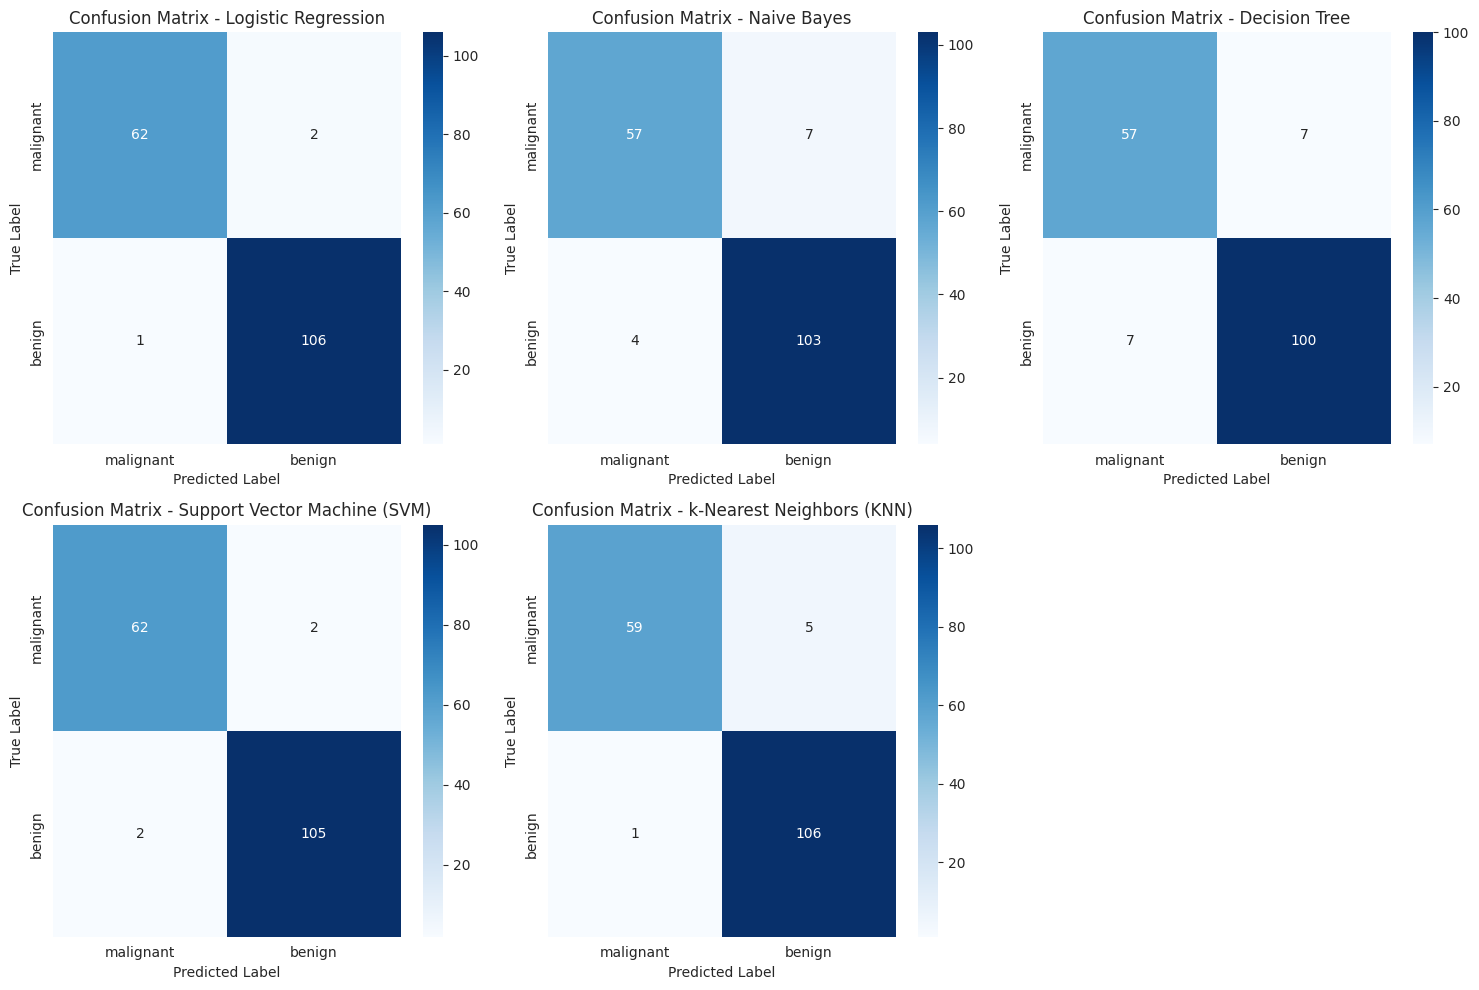

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

num_models = len(trained_models)
num_cols = 3
num_rows = (num_models + num_cols - 1) // num_cols

fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(5 * num_cols, 5 * num_rows))
axes = axes.flatten()

print("creating heat map for confusion matrix ")
for i, (name, model) in enumerate(trained_models.items()):
    #predicting on test data
    y_pred = model.predict(X_test)

    # calculating confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # heat map plotting
    sns.heatmap(
        cm,
        annot=True, #show values inside the cells
        fmt='d', # number formatting as integers
        cmap='Blues', # color map selection
        ax=axes[i],
        xticklabels=data.target_names,
        yticklabels=data.target_names
    )
    axes[i].set_title(f'Confusion Matrix - {name}', fontsize=12)
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

# hiding any unused curves
for j in range(num_models, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#منحنى ROC
#مساحة تحت المنحنى AUC

تُظهر منحنيات
ROC
 المقايضة بين معدل الإيجابيات الحقيقية
 (True Positive Rate أو Sensitivity)
 ومعدل الإيجابيات الكاذبة
 (False Positive Rate أو 1 - Specificity).

مساحة تحت المنحنى (AUC) توفر قيمة عددية لملخص أ

plotting ROC curve and calculating AUC values...


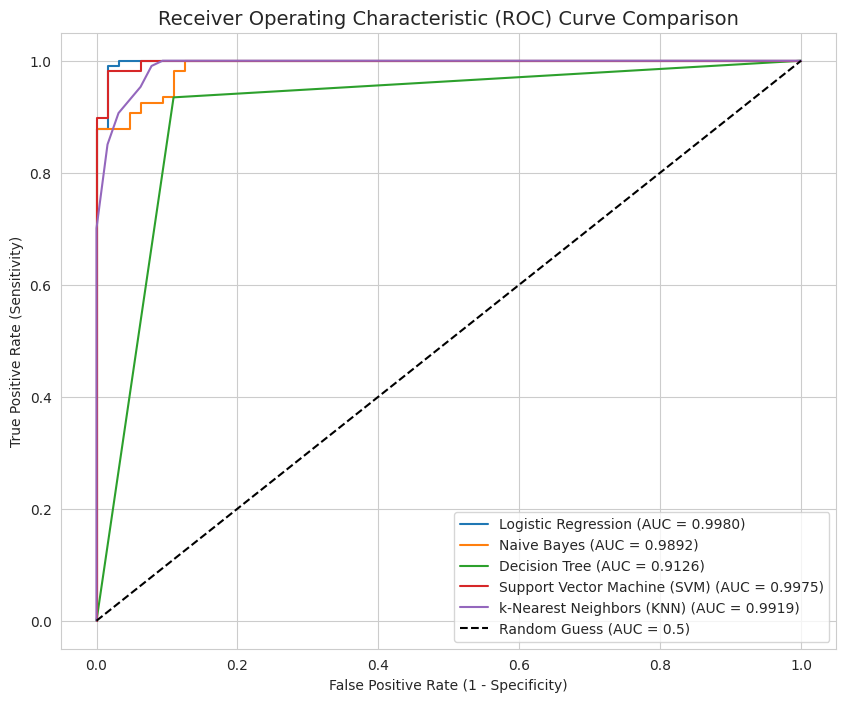

In [ ]:
# Cell 9: Plot ROC Curves and Calculate AUC (Task 3.3 & 4.1)
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

print("plotting ROC curve and calculating AUC values...")

# prediction probabilities for each module
for name, model in trained_models.items():

    # Obtain the probabilities for the positive class (1).
    # Predict_proba is used for almost all models.
    # Note: Probability=True is checked for the SVM model in cell 6.

    try:
        y_prob = model.predict_proba(X_test)[:, 1]
    except AttributeError:

      # Some models, like the default SVM, may not support predict_proba.
      # But we've already set it in cell 6, so it should work.

        print(f"تحذير: النموذج {name} لا يدعم predict_proba. سيتم تخطيه.")
        continue
      # ROC Curve Calculation: False Positive Rate (FPR) and True Positive Rate (TPR)

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    # calculating AUC
    roc_auc = roc_auc_score(y_test, y_prob)

    #  plotting the curve
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

# plotting random line (Random Guess)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5)')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

مقارنة حدود القرار باستخدام مخطط تشتت (تبعثر) وميزتين مختارتين:
بعد العودة إلى دراسات مرجعية سابقة وخبرات من أطباء شعاعيين وأطباء أورام، يعتبر هؤلاء الباحثين أن أهم ميزتين Features في تشخيص أورام الثدي هما mean radius, mean texture.
آلية العمل ستكون على الشكل التالي:
1.	اختيار الميزتين السابقتين فقط.
2.	إعادة تدريب نماذج من الخوارزميات الخمسة على الميزتين المذكورتين فقط.
3.	إنشاء شبكة Meshgrade تغطي مجال القيم الخاصة بالميزتين السابقتين.
4.	عرض حدود القرار لإظهار حدود التصنيف لكل فئة.
5.	 المخطط المبعثر: يتم عرض نقاط بيانات الاختبار الحقيقية (X_subset) فوق الخريطة اللونية، حيث يمثل لون النقطة التسمية الحقيقية لها (y_test)، مما يوضح مدى صحة تصنيف كل نقطة بناءً على حد القرار.


Generating Decision Boundaries for Two Features...


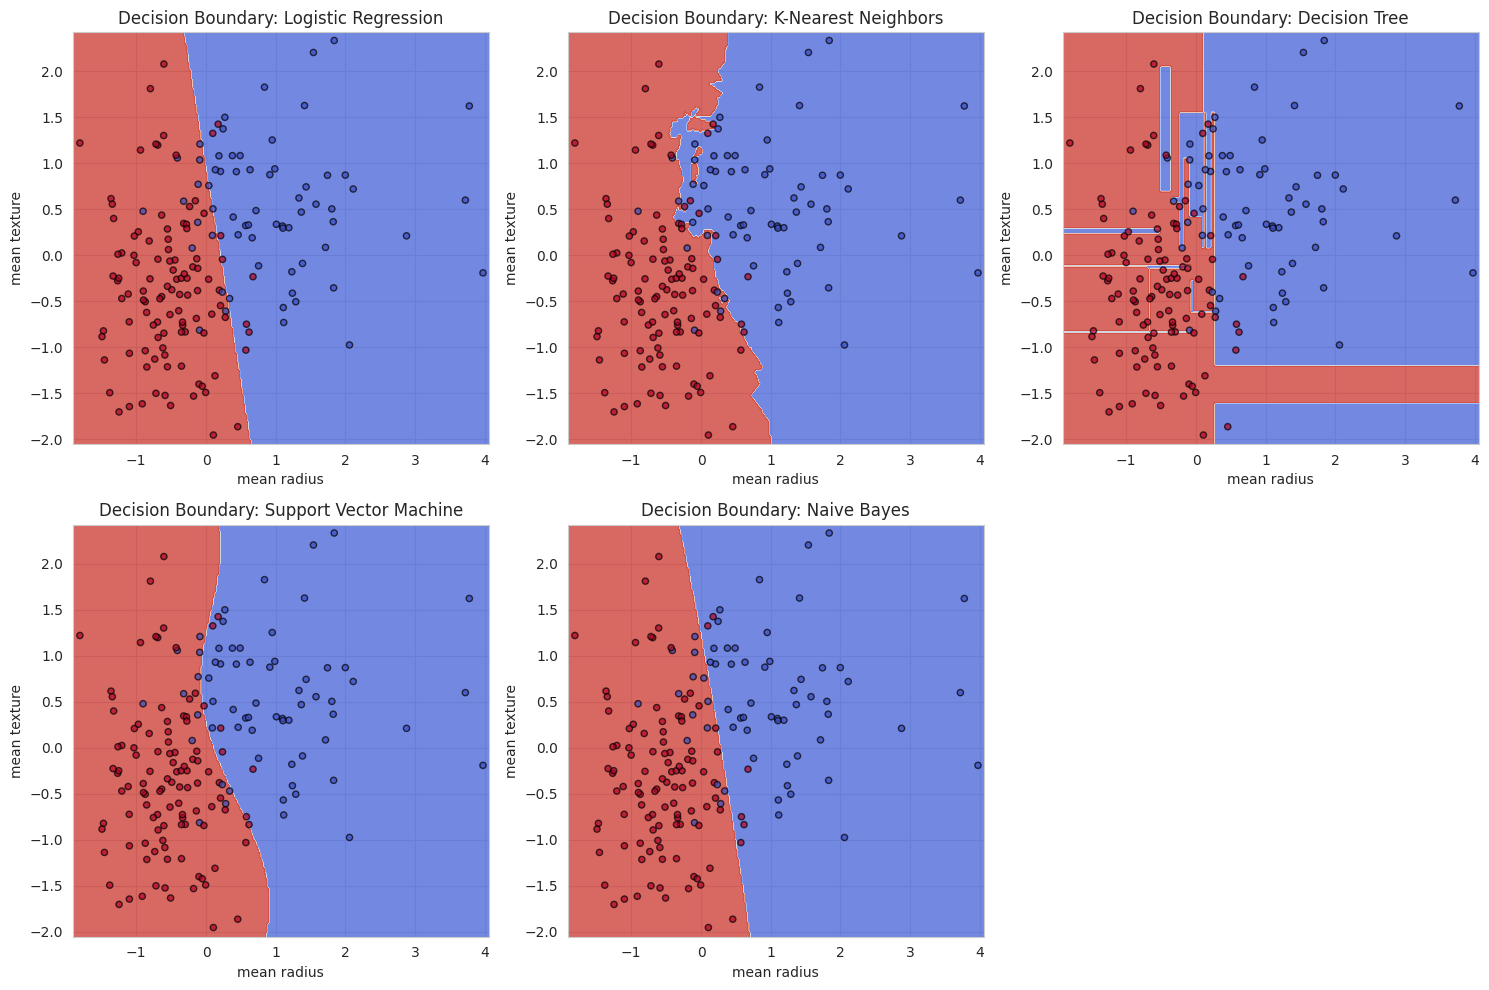

In [ ]:
# Convert X_train and X_test explicitly to NumPy arrays to resolve the slicing error (KeyError)
X_train_np = np.array(X_train)
X_test_np = np.array(X_test)

# Task: Compare the decision boundaries using a scatter plot with two selected features (Task 4.3).

# Select the first two features for 2D visualization (e.g., 'mean radius' and 'mean texture')
X_train_subset = X_train_np[:, :2]
X_test_subset = X_test_np[:, :2]

# Define a new set of models to be trained ONLY on the two selected features.
# This is necessary because decision boundaries are feature-dependent.
subset_models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=10),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Support Vector Machine': SVC(kernel='rbf', random_state=42),
    'Naive Bayes': GaussianNB()
}

# Train the new models on the two-feature subset of the training data
# We use the original 'y_train' labels
for name, model in subset_models.items():
    model.fit(X_train_subset, y_train)

# --- Decision Boundaries Visualization Cell (using Meshgrid) ---

# Define the meshgrid boundaries using the test subset data
h = .02  # Step size in the meshgrid
x_min, x_max = X_test_subset[:, 0].min() - 0.1, X_test_subset[:, 0].max() + 0.1
y_min, y_max = X_test_subset[:, 1].min() - 0.1, X_test_subset[:, 1].max() + 0.1
# Create meshgrid to cover the feature space
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Setup the plot figure layout
num_models = len(subset_models)
num_cols = 3
num_rows = (num_models + num_cols - 1) // num_cols
fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(15, 10))
axes = axes.flatten()

print("Generating Decision Boundaries for Two Features...")

# Assuming 'data' object is available to retrieve feature names
try:
    feature_names = data.feature_names
    feature1_label = feature_names[0] # Example: mean radius
    feature2_label = feature_names[1] # Example: mean texture
except NameError:
    feature1_label = 'Feature 1 (Index 0)'
    feature2_label = 'Feature 2 (Index 1)'


for i, (name, model) in enumerate(subset_models.items()):
    # Predict the class for every point in the meshgrid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot the color-coded decision regions (Task 7)
    # The 'coolwarm' colormap represents the two classes (0 and 1)
    axes[i].contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)

    # Plot the actual test data points (Task 4.3 - Scatter Plot)
    # 'y_test' is used for coloring the points to show the True Label
    scatter = axes[i].scatter(X_test_subset[:, 0], X_test_subset[:, 1], c=y_test,
                              edgecolor='k', s=20, cmap=plt.cm.coolwarm, alpha=0.7)

    # Set plot limits, title, and labels
    axes[i].set_xlim(xx.min(), xx.max())
    axes[i].set_ylim(yy.min(), yy.max())
    axes[i].set_xlabel(feature1_label)
    axes[i].set_ylabel(feature2_label)
    axes[i].set_title(f'Decision Boundary: {name}', fontsize=12)

# Hide any unused subplots for clean output
for j in range(num_models, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#توليف وتحسين النماذج Model Tuning:
تهدف هذه الخطوة إلى إيجاد أفضل مجموعة قيم Optimal Set للمعاملات التي لا يتم تعلمها مباشرة من البيانات مثل قيمة K في KNN أو نوع النواة Kernel في SVM. هذا يضمن أن النموذج يعمل بأقصى كفاءة ويقلل من مشكلة فرط التخصيص Overfitting أو نقص التخصيص Underfitting.


In [ ]:

from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

print("Starting Hyperparameter Tuning using GridSearchCV...")

# Define F1-score as the optimization metric (scorer)
# We use 'macro' average as the classes are assumed slightly imbalanced and need equal weight.
scorer = make_scorer(f1_score, average='macro')

# 1. Support Vector Machine (SVM) Tuning Parameters
param_grid_svc = {
    'C': [0.1, 1, 10, 100],      # Regularization parameter
    'gamma': ['scale', 'auto', 0.1, 1], # Kernel coefficient
    'kernel': ['rbf', 'linear']  # Kernel type
}
grid_svc = GridSearchCV(SVC(random_state=42), param_grid_svc, refit=True, verbose=2, cv=5, scoring=scorer)
print("\nTuning SVM...")
grid_svc.fit(X_train, y_train)

# 2. K-Nearest Neighbors (KNN) Tuning Parameters
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15], # K value
    'weights': ['uniform', 'distance'],  # Weighting function
    'metric': ['euclidean', 'manhattan'] # Distance metric
}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, refit=True, verbose=2, cv=5, scoring=scorer)
print("\nTuning KNN...")
grid_knn.fit(X_train, y_train)

# 3. Decision Tree (DT) Tuning Parameters
param_grid_dt = {
    'max_depth': [3, 5, 7, 9, None],     # Max depth of the tree (None means unlimited)
    'min_samples_leaf': [1, 3, 5, 10],   # Minimum number of samples required to be at a leaf node
    'criterion': ['gini', 'entropy']     # Split quality measure
}
grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_dt, refit=True, verbose=2, cv=5, scoring=scorer)
print("\nTuning Decision Tree...")
grid_dt.fit(X_train, y_train)


# --- RESULTS AND UPDATING MODELS ---

tuned_models = {
    'Tuned SVM': grid_svc.best_estimator_,
    'Tuned KNN': grid_knn.best_estimator_,
    'Tuned Decision Tree': grid_dt.best_estimator_
}

print("\n--- Tuning Results ---")
print(f"Best SVM Parameters: {grid_svc.best_params_}")
print(f"Best KNN Parameters: {grid_knn.best_params_}")
print(f"Best DT Parameters: {grid_dt.best_params_}")
# Note: These best_estimator_ objects should replace the default models for final comparison.

Starting Hyperparameter Tuning using GridSearchCV...

Tuning SVM...
Fitting 5 folds for each of 32 candidates, totalling 160 fits
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.0s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.0s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.0s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.0s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.0s
[CV] END ......................C=0.1, gamma=auto, kernel=rbf

#مقارنة النماذج الأساسية مع النماذج المحسبة بواسطة مخططات ROC وقيم معامل AUC:
من خلال ROCو AUC ستكون لدينا مقارنة بصرية وعددية للخوارزميات ال 8 الناتجة حتى الآن (الخمس خوارزميات الأساسية وال 3 خوارزميات التي قمنا بتحسينها سابقاً).


Generating ROC Curves and AUC Scores...


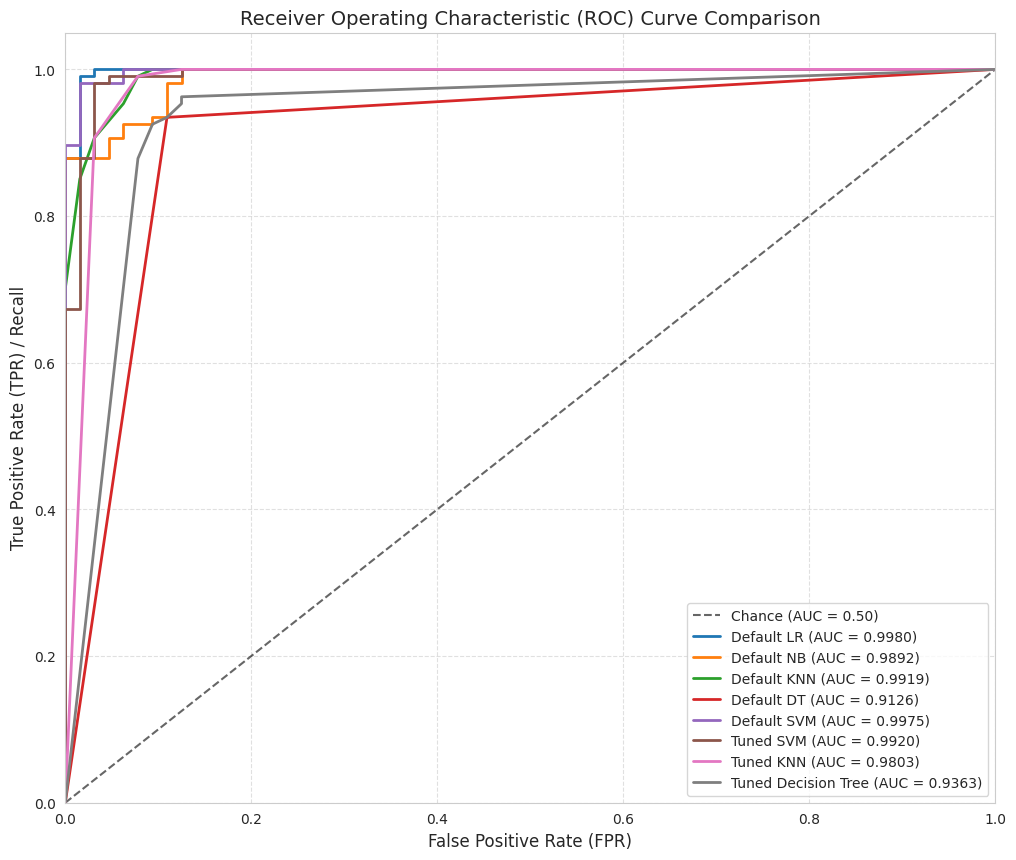

In [ ]:
from sklearn.svm import SVC
import itertools

# Create a dictionary of all default models (assumed trained on X_train, y_train in Task 3)
default_models = {
    'Default LR': LogisticRegression(random_state=42, max_iter=1000).fit(X_train, y_train),
    'Default NB': GaussianNB().fit(X_train, y_train),
    'Default KNN': KNeighborsClassifier(n_neighbors=10).fit(X_train, y_train), # Assuming default n_neighbors=10
    'Default DT': DecisionTreeClassifier(random_state=42).fit(X_train, y_train),
    'Default SVM': SVC(kernel='rbf', random_state=42, probability=True).fit(X_train, y_train)
    # SVC often needs probability=True for predict_proba; decision_function is safer otherwise.
}

# Consolidate default and tuned models (assuming 'tuned_models' is available from Task 6)
all_models = {**default_models, **tuned_models}

# Step 2: Plot ROC Curves and Calculate AUC Scores

plt.figure(figsize=(12, 10))
# Plot the baseline (Random Guess)
plt.plot([0, 1], [0, 1], 'k--', label='Chance (AUC = 0.50)', alpha=0.6)

# Cycling through colors for better visualization differentiation
colors = itertools.cycle(['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f'])

print("Generating ROC Curves and AUC Scores...")

for name, model in all_models.items():

    # Get the predicted probabilities/scores for the positive class (Class 1)
    try:
        if hasattr(model, "predict_proba"):
            # Use predict_proba for models that support it (LR, NB, DT, KNN)
            y_pred_proba = model.predict_proba(X_test)[:, 1]
        elif hasattr(model, "decision_function"):
            # Use decision_function for SVM if probability=False was used
            y_pred_proba = model.decision_function(X_test)
        else:
            print(f"Skipping {name}: Model does not support score output.")
            continue

        # Calculate False Positive Rate (FPR), True Positive Rate (TPR), and thresholds
        fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

        # Calculate Area Under the Curve (AUC)
        roc_auc = roc_auc_score(y_test, y_pred_proba)

        # Plot the ROC curve
        plt.plot(fpr, tpr, color=next(colors),
                 label=f'{name} (AUC = {roc_auc:.4f})', linewidth=2)

    except Exception as e:
        print(f"Error processing {name} - Did you train the model with probability=True?: {e}")
        continue


# Step 3: Configure and Display the Plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR) / Recall', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison', fontsize=14)
plt.legend(loc="lower right", fontsize='medium')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

الخلاصة النهائية من المشروع ككل:
في التطبيقات الطبية، فإن الخطأ الأكثر خطورة هو السلبي الخاطئ (False Negative - FN)، أي تشخيص شخص مريض بالسرطان على أنه سليم.
منهجياً سنعتمد على قيمة ACU لاختيار الخوارزمية المناسبة لتصنيف أورام الثدي بواسطة أنماط تشخيص طبي مشابهة لأنماط التشخيص التي اتبعها الباحثون عند جمع البيانات الخاصة بمجوعة بياناتنا لمستخدمة في هذا البحث.
وحسب المعايير السابقة سنعتمد خوارزمية الانحدار اللوجيستي LR.
ولكن من وجهة نظر أخرى وعند دراستنا لحدود القرار Decision Boundaries لاحظنا أن هذه الخوارزمية – مثل كل الخوارزميات الخطية – تقوم بالفصل الخطي بين الميزات وتهمل تأثير القيم المتداخلة. بينما تقوم الخوارزميات اللاخطية مثل SVM بعملية الفصل بين هذه الأمثلة بشكل ممتاز وبدون تعقيد بالحدود. ولا بد لنا أن نذكر أن دراستنا اعتمدت على ميزتين Features فقط حدد الباحثون أنهما الأكثر تأثيراً في التصنيف.
النتيجة الخاصة بالبحث من وجهة نظرنا:
على الرغم من أن خوارزمية الانحدار اللوجيستي تفوقت على جميع الخوارزميات من ناحية المعايير التقويمية. ولكن سنفضل خوارزمية آلة شعاع الدعم SVM وذلك لاعتبارات تتعلق بطبيعة البيانات من جهة وللتقارب بين نتائج المعايير التقويمية لل SVMمع ال LR.
